<a href="https://colab.research.google.com/github/KYAWZIN2910/AI-Image-Generator/blob/main/imageGenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install diffusers transformers gradio accelerate

In [ ]:
# @title
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
# @title
!pip show torch

Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision


In [ ]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

#model used for generating images for this project from hugging face
model_id1 = "dreamlike-art/dreamlike-diffusion-1.0"
model_id2 = "runwayml/stable-diffusion-v1-5"

# Check if GPU is available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(model_id1, torch_dtype=dtype, use_safetensors=True)
pipe = pipe.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [ ]:
# Optimize for memory usage (m2)
pipe.enable_model_cpu_offload()
torch.cuda.empty_cache()

In [ ]:
prompt = "photo, a church in the middle of a field of crops, bright cinematic lighting, gopro, fisheye lens"

In [ ]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

[PROMPT]:  photo, a church in the middle of a field of crops, bright cinematic lighting, gopro, fisheye lens


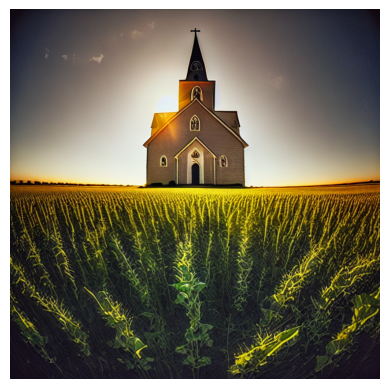

In [ ]:
print("[PROMPT]: ",prompt)
plt.imshow(image);
plt.axis('off');
image.save("./result.jpg")

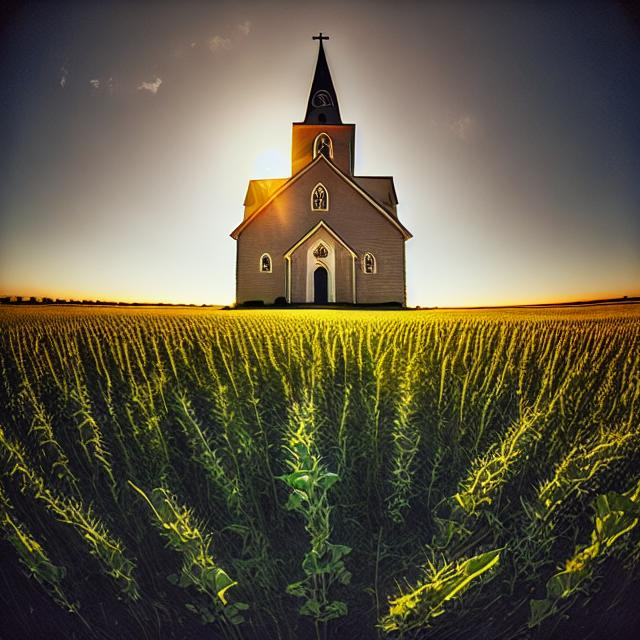

In [ ]:
from IPython.display import Image
Image('./result.jpg')

In [ ]:
prompt2 = "a picture of a woman playing with her dog at the shore in the evening"
image = pipe(prompt2).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

[PROMPT]:  a picture of a woman playing with her dog at the shore in the evening


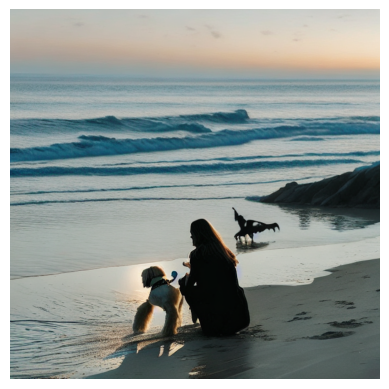

In [ ]:
print("[PROMPT]: ",prompt2)
plt.imshow(image);
plt.axis('off');

In [ ]:
#setting with the parameters
def generate_image(pipe, promptm, params):
    img = pipe(prompt, **params).images

    num_images = len(img)
    if num_images >1:
      fig,ax = plt.subplots(nrows=1,ncols=num_images)
      for i in range(num_images):
        ax[i].imshow(img[i])
        ax[i].axis('off')
    else:
      fig = plt.figure()
      plt.imshow(img[0])
      plt.axis('off')
    plt.tight_layout()

In [ ]:
prompt = "A rainy day in the field where kids are playing football"
params = {}

  0%|          | 0/100 [00:00<?, ?it/s]

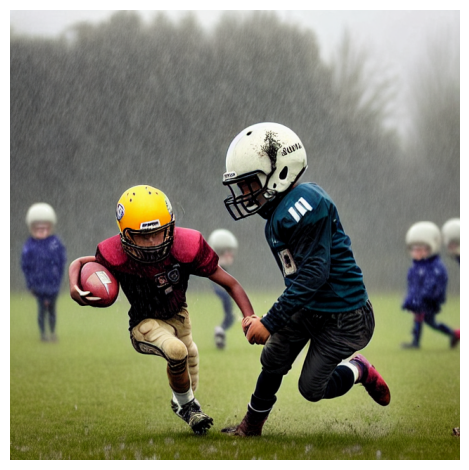

In [ ]:
params = {'num_inference_steps': 100}
generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

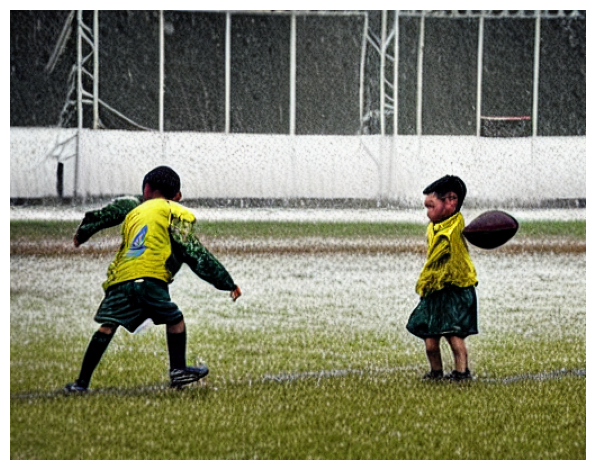

In [ ]:
#height and width

params = {
    'num_inference_steps': 100,
    'height': 400,
    'width': 512
}

generate_image (pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

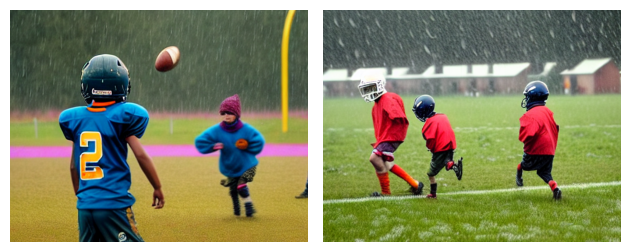

In [ ]:
#num_images_per_prompt
params = {'num_inference_steps': 100, 'num_images_per_prompt': 2, 'height': 400,
    'width': 512}

generate_image(pipe, prompt, params)